In [6]:
import os
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn
import multiprocessing
from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn

import yaml

# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit

# 概率比较部分
from scipy.special import gammaln
import torch.distributions as dist

# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation

In [9]:
file_load_once = 1
param = 0
index = 0

DE_sim = DESimulation("sim_config/DE_2ms.yaml")

# test_cevns_sim.pe_gain_std = 2.4e6


muon_file_list = []
for i in range(file_load_once):
    # print(i)
    file_index = index * file_load_once + i
    filename = "muon_track/muon_track." + str(file_index) + ('.npy')
    # print(filename)
    muon_file_list.append(filename)

DE_sim.generate_muon_points(muon_file_list)
DE_sim.generate_DE_points()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 347.10it/s]


First muon track file: muon_track/muon_track.0.npy
Last muon track file: muon_track/muon_track.0.npy
Number of muon events: 3136
merged_muon_array data type: [('eventId', '<i4'), ('type', 'i1'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]
dense_muon_points data type:  [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]
Start sorting DE's time
Finish sorting DE's time


In [10]:
DE_sim.delayed_electron

array([(   0,  36.03542216, 130.29420665, 8.08977444e-02, 8.29253305e-02),
       (   0,  29.9855827 , 134.514433  , 8.08977444e-02, 8.29544483e-02),
       (   0,  37.67777902, 126.8311521 , 8.08977444e-02, 8.29669224e-02),
       ...,
       (3135, -51.54997028,  17.2364624 , 3.05842566e+02, 3.07837949e+02),
       (3135, -53.03746562,  29.41584793, 3.05842566e+02, 3.07838202e+02),
       (3135, -62.71081771,  -8.81648519, 3.05842566e+02, 3.07841906e+02)],
      dtype=[('eventId', '<i4'), ('xd', '<f8'), ('yd', '<f8'), ('muon_time', '<f8'), ('e_time', '<f8')])

In [11]:
xi = np.stack((DE_sim.delayed_electron['xd'], DE_sim.delayed_electron['yd']), axis=1)

In [14]:
results = []
for pmt_id in tqdm(range(128)):  # 仅对顶部pmt结果进行模拟
    result = DE.calculate_pattern(
        pmt_id,
        DE_sim.LCE_xs,
        DE_sim.LCE_ys,
        DE_sim.LCE_value_true,
        xi,
    )
    results.append(result)
    # 等待所有任务完成并获取结果
results = np.array(results)
pattern = results.T

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [03:09<00:00,  1.48s/it]


In [16]:
gamma = np.random.normal(1, 0.265, len(pattern))
alter_pattern = pattern * DE_sim.single_electron_gain * gamma[:, np.newaxis]
alter_pattern[alter_pattern < 0] = 0  # 随机效应导致小于0期望值的修正
alter_pe_pattern = np.random.poisson(alter_pattern)

In [18]:
alter_pe_pattern[0],alter_pe_pattern[1]

(array([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 7, 2, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 6, 3, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0]))

In [23]:
index = 20
channel_indices = np.repeat(np.arange(128), alter_pe_pattern[index])
pe_area = np.random.normal(DE_sim.pe_gain, DE_sim.pe_gain_std, size=len(channel_indices)) / DE_sim.pe_gain
pe_time_delta = np.random.normal(0, 0.19, size=len(channel_indices))

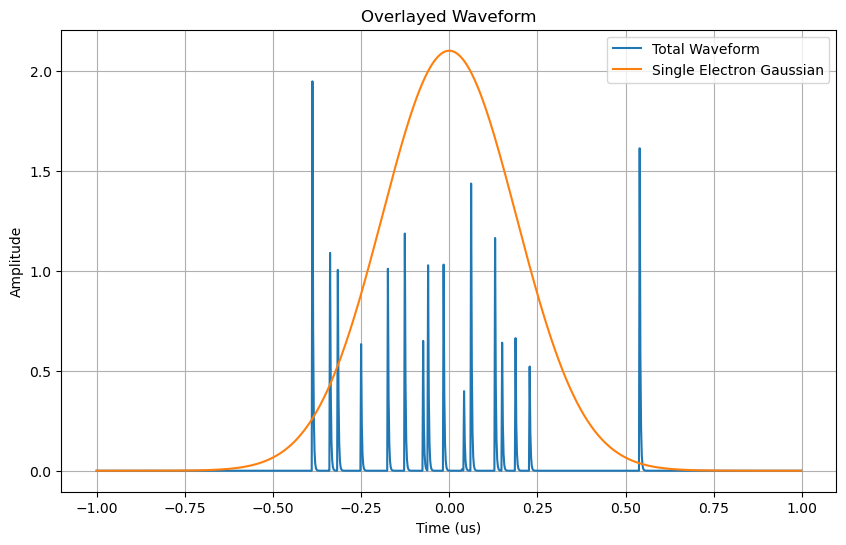

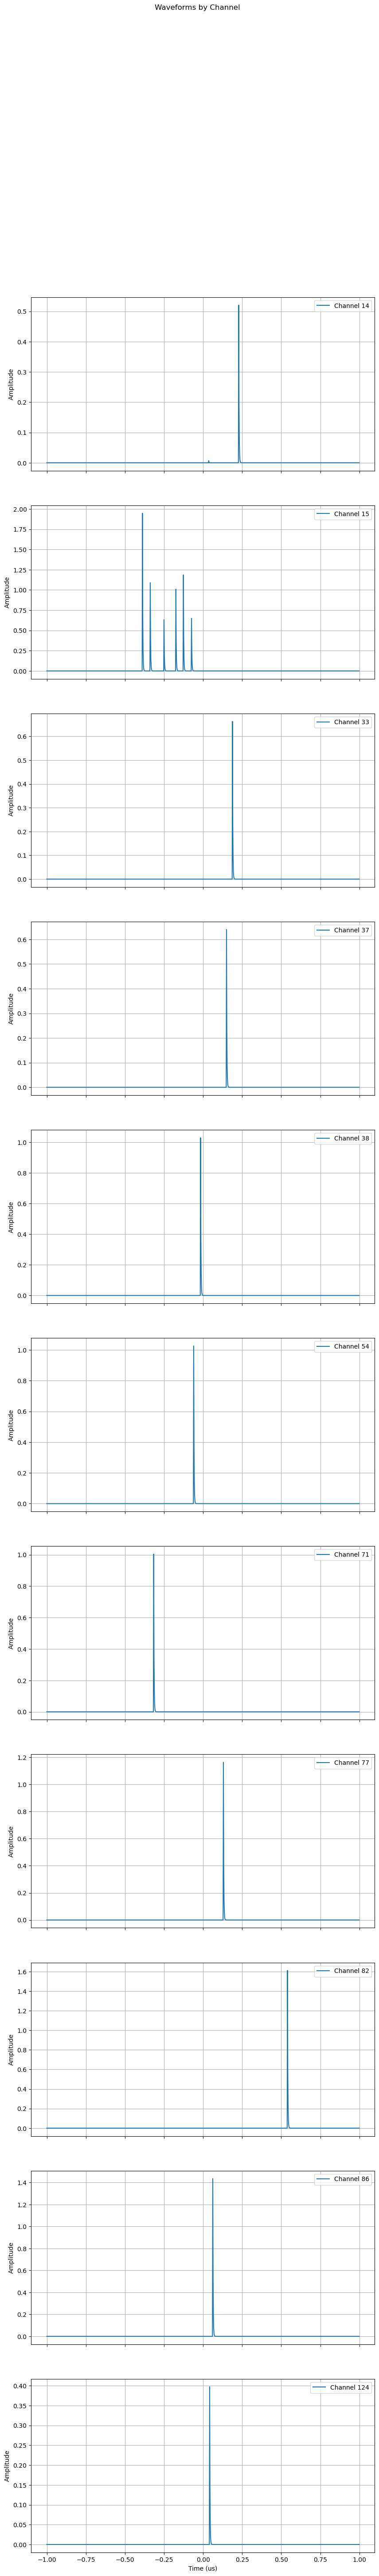

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm import tqdm

def generate_pulse_waveform(time, amplitude, pulse_shape, total_time, time_step):
    """
    生成单个脉冲的波形

    参数:
    time (float): 脉冲的时间
    amplitude (float): 脉冲的大小
    pulse_shape (np.ndarray): 脉冲的形状
    total_time (float): 总时间
    time_step (float): 时间步长

    返回:
    np.ndarray: 单个脉冲的波形
    """
    num_steps = int(total_time / time_step)
    waveform = np.zeros(num_steps)
    pulse_length = len(pulse_shape)
    start_index = int(time / time_step + num_steps/2)
    end_index = start_index + pulse_length

    if end_index < num_steps:
        waveform[start_index:end_index] = amplitude * pulse_shape
    else:
        waveform[start_index:] = (amplitude * pulse_shape)[:(num_steps - start_index)]

    return waveform

def plot_waveforms(pulse_times, pulse_amplitudes, pulse_shape, total_time, time_step):
    """
    绘制叠加的总波形图

    参数:
    pulse_times (list): 每个脉冲的时间
    pulse_amplitudes (list): 每个脉冲的大小
    pulse_shape (np.ndarray): 脉冲的形状
    total_time (float): 总时间
    time_step (float): 时间步长
    """
    num_steps = int(total_time / time_step)
    total_waveform = np.zeros(num_steps)

    for time, amplitude in zip(pulse_times, pulse_amplitudes):
        pulse_waveform = generate_pulse_waveform(time, amplitude, pulse_shape, total_time, time_step)
        total_waveform += pulse_waveform

    time_axis = np.arange(-total_time/2, total_time/2, time_step)
    single_electron_shape = norm.pdf(time_axis, 0, 0.19)
    plt.figure(figsize=(10, 6))
    plt.plot(time_axis, total_waveform, label='Total Waveform')
    plt.plot(time_axis, single_electron_shape, label='Single Electron Gaussian')
    plt.xlabel('Time (us)')
    plt.ylabel('Amplitude')
    plt.title('Overlayed Waveform')
    plt.legend()
    plt.grid(True)
    plt.savefig('figure/se_wf.png')
    plt.show()

def plot_waveforms_by_channel(pulse_times, pulse_amplitudes, pulse_channels, pulse_shape, total_time, time_step):
    """
    按通道分别绘制波形图

    参数:
    pulse_times (list): 每个脉冲的时间
    pulse_amplitudes (list): 每个脉冲的大小
    pulse_channels (list): 每个脉冲的通道
    pulse_shape (np.ndarray): 脉冲的形状
    total_time (float): 总时间
    time_step (float): 时间步长
    """
    unique_channels = np.unique(pulse_channels)
    num_channels = len(unique_channels)
    num_steps = int(total_time / time_step)
    time_axis = np.arange(-total_time/2, total_time/2, time_step)

    fig, axs = plt.subplots(num_channels, 1, figsize=(10, 6 * num_channels), sharex=True)

    for i, channel in enumerate(unique_channels):
        channel_waveform = np.zeros(num_steps)
        for time, amplitude, ch in zip(pulse_times, pulse_amplitudes, pulse_channels):
            if ch == channel:
                pulse_waveform = generate_pulse_waveform(time, amplitude, pulse_shape, total_time, time_step)
                channel_waveform += pulse_waveform

        axs[i].plot(time_axis, channel_waveform, label=f'Channel {channel}')
        axs[i].set_ylabel('Amplitude')
        axs[i].legend()
        axs[i].grid(True)

    axs[-1].set_xlabel('Time (us)')
    plt.suptitle('Waveforms by Channel')
    plt.savefig('figure/se_wf_ch.pdf')
    plt.show()

# 示例用法
if __name__ == "__main__":
    # 定义脉冲的时间和大小
    # pulse_times = [0.1, 0.5, -0.3, -0.5]
    # pulse_amplitudes = [1.0, 0.8, 1.2, 0.6]
    # pulse_channels = [1, 1, 2, 2]
    pulse_times = pe_time_delta
    pulse_amplitudes = pe_area
    pulse_channels = channel_indices

    # 定义脉冲的形状（例如，高斯脉冲）
    pulse_length = 100
    pulse_shape = np.exp(-(100*np.linspace(0, 1, pulse_length)))

    # 定义总时间和时间步长 us
    total_time = 2.0
    time_step = 0.002

    # 绘制叠加的总波形图
    plot_waveforms(pulse_times, pulse_amplitudes, pulse_shape, total_time, time_step)

    # 按通道分别绘制波形图
    plot_waveforms_by_channel(pulse_times, pulse_amplitudes, pulse_channels, pulse_shape, total_time, time_step)

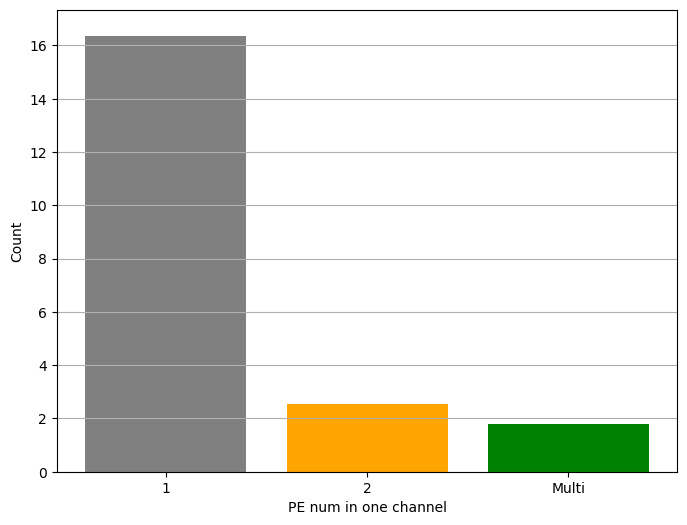

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plot_element_distribution(array):
    """
    绘制数组中 0 元素、1 元素和 2 元素的数量分布条形图

    参数:
    array (np.ndarray): 输入的数组
    """
    # 计算 0 元素、1 元素和 2 元素的数量
    unique, counts = np.unique(array, return_counts=True)
    element_counts = dict(zip(unique, counts))

    # 确保 0、1、2 元素的数量都存在
    counts_0 = element_counts.get(0, 0)
    counts_1 = element_counts.get(1, 0)
    counts_2 = element_counts.get(2, 0)
    counts_multi = np.sum(counts) - counts_0 - counts_1 - counts_2

    # 准备数据
    elements = ['1', '2','Multi']
    counts = [counts_1 / np.sum(counts) * 128, 
              counts_2 / np.sum(counts) * 128, 
              counts_multi / np.sum(counts) * 128]

    # 绘制条形图
    plt.figure(figsize=(8, 6))
    plt.bar(elements, counts, color=['grey', 'orange', 'green','blue'])
    plt.xlabel('PE num in one channel')
    plt.ylabel('Count')
    plt.ylim(0, max(counts) + 1)
    plt.grid(axis='y')
    plt.savefig('figure/se_pe_per_channel.png')
    plt.show()
    
    return counts

# 创建一个示例数组
array = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2])

# 绘制数组中 0 元素、1 元素和 2 元素的数量分布条形图
counts = plot_element_distribution(alter_pe_pattern)

In [37]:
counts = np.array(counts)
se_size = np.sum(np.array([1,2,3]) * 220 * counts) / 1024

In [44]:
se_data_rate = len(alter_pe_pattern) * se_size / (1024) / (300)

In [45]:
se_data_rate

191.8471589406331

In [56]:
muon_time = np.unique(DE_sim.delayed_electron['muon_time'])
e_time = DE_sim.delayed_electron['e_time']

In [57]:
import numpy as np

def calculate_time_distances(muon_time, e_time):
    """
    计算每个电子事件距离之前最近的一个缪子事件的时间距离

    参数:
    muon_time (np.ndarray): 缪子事件的时间数组
    e_time (np.ndarray): 电子事件的时间数组

    返回:
    np.ndarray: 每个电子事件距离之前最近的一个缪子事件的时间距离
    """
    # 确保 muon_time 和 e_time 是排序的
    muon_time = np.sort(muon_time)
    e_time = np.sort(e_time)

    # 使用 searchsorted 找到每个电子事件之前最近的缪子事件的索引
    indices = np.searchsorted(muon_time, e_time, side='right') - 1

    # 计算时间距离
    time_distances = e_time - muon_time[indices]

    return time_distances

# 计算时间距离
time_distances = calculate_time_distances(muon_time, e_time)
print("每个电子事件距离之前最近的一个缪子事件的时间距离:")
print(time_distances)

每个电子事件距离之前最近的一个缪子事件的时间距离:
[0.00202759 0.0020567  0.00206918 ... 1.99538308 1.99563633 1.99933978]


In [68]:
dead_time_list = np.array([2,5,10,15,20,30,40]) / 1000
ratio = np.array([len(time_distances[time_distances>i]) / len(time_distances) for i in dead_time_list])

In [73]:
ratio * se_data_rate

array([188.07545161, 150.38616734, 121.71300122, 104.53999195,
        92.13436809,  74.34608226,  61.59032098])

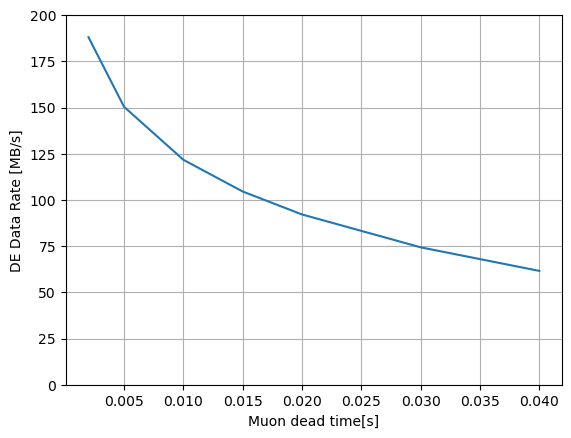

In [72]:
plt.plot(dead_time_list,ratio * se_data_rate)
plt.ylim(0,200)
plt.xlabel("Muon dead time[s]")
plt.ylabel("DE Data Rate [MB/s]")
plt.grid()
plt.savefig("figure/se_data_dead_time.png")
plt.show()

In [75]:
92.13436809 * 3600 * 24* 365 / (1024)**3

2.7060037777630983

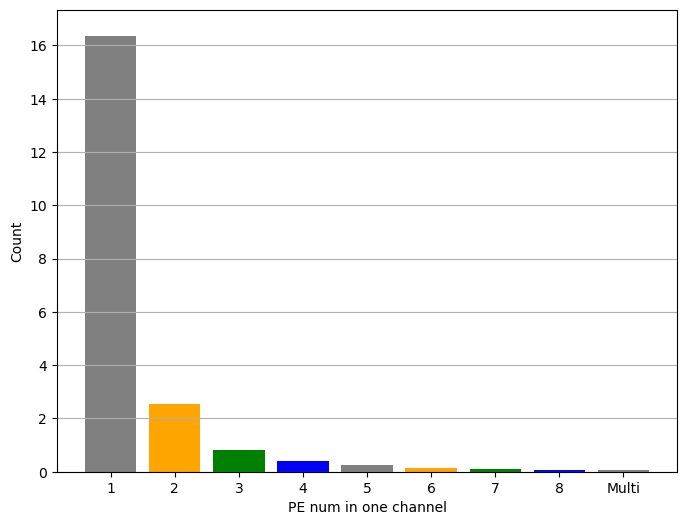

In [80]:
import numpy as np
import matplotlib.pyplot as plt

def plot_element_distribution(array):
    """
    绘制数组中 0 元素、1 元素和 2 元素的数量分布条形图

    参数:
    array (np.ndarray): 输入的数组
    """
    # 计算 0 元素、1 元素和 2 元素的数量
    unique, counts = np.unique(array, return_counts=True)
    element_counts = dict(zip(unique, counts))

    # 确保 0、1、2 元素的数量都存在
    count_list = []
    for pe_num in range(0,9):
        count_list.append(element_counts.get(pe_num, 0))
    counts_multi = np.sum(counts) - np.sum(count_list)
    count_list.append(counts_multi)

    # 准备数据
    elements = ['1', '2','3', '4', '5', '6', '7', '8', 'Multi']
    counts = np.array(count_list) / len(array)

    # 绘制条形图
    plt.figure(figsize=(8, 6))
    plt.bar(elements, counts[1:], color=['grey', 'orange', 'green','blue'])
    plt.xlabel('PE num in one channel')
    plt.ylabel('Count')
    plt.ylim(0, max(counts[1:]) + 1)
    plt.grid(axis='y')
    plt.savefig('figure/se_pe_per_channel_9.png')
    plt.show()
    
    return counts

# 创建一个示例数组
array = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2])

# 绘制数组中 0 元素、1 元素和 2 元素的数量分布条形图
counts = plot_element_distribution(alter_pe_pattern)

In [89]:
size_small_cell = np.sum(np.arange(1,10,1) * 0.1 * counts[1:])
size_small_cell

2.9075049971640956

In [87]:
counts

array([1.07327121e+02, 1.63409715e+01, 2.52508395e+00, 8.04892593e-01,
       4.20488182e-01, 2.46794959e-01, 1.46564910e-01, 8.52663634e-02,
       4.83009838e-02, 5.45159302e-02])

In [91]:
se_data_rate_small_cell = len(alter_pe_pattern) * size_small_cell / (1024) / (300)

In [92]:
se_data_rate_small_cell

96.83452018229167

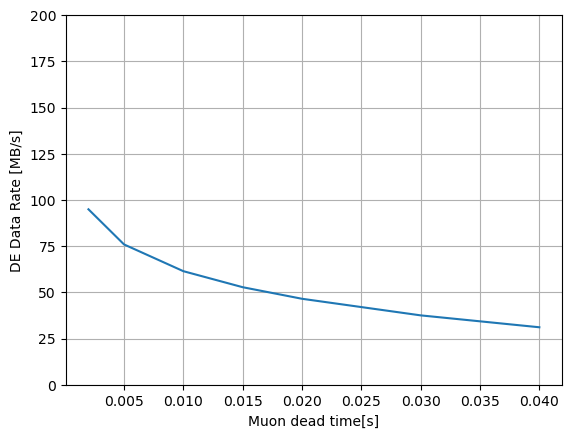

In [93]:
plt.plot(dead_time_list,ratio * se_data_rate_small_cell)
plt.ylim(0,200)
plt.xlabel("Muon dead time[s]")
plt.ylabel("DE Data Rate [MB/s]")
plt.grid()
plt.savefig("figure/se_data_dead_time_small_cell.png")
plt.show()

In [96]:
dead_time_list

array([0.002, 0.005, 0.01 , 0.015, 0.02 , 0.03 , 0.04 ])

In [98]:
(ratio * se_data_rate_small_cell)[dead_time_list == 0.02]

array([46.50466223])